In [1]:
import engine
import numpy
import struct
from array import array

%matplotlib inline
import matplotlib.pyplot as pyplot

In [2]:
# Modified code from the kaggle page where I downloaded the MNIST data for data loading.
def load_mnist_data(images_filepath, labels_filepath):
    with open(labels_filepath, 'rb') as file:
        magic, size = struct.unpack(">II", file.read(8))
        if magic != 2049:
            raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
        labels = array("B", file.read()) 
            
    with open(images_filepath, 'rb') as file:
        magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
        if magic != 2051:
            raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
        image_data = array("B", file.read())
            
    images = numpy.zeros((size, rows * cols))

    for i in range(size):
        images[i] = numpy.array(image_data[i * rows * cols:(i + 1) * rows * cols])
    
    return engine.Tensor(images), engine.Tensor(numpy.array(labels).astype(int))

# For making sure the digits are loaded properly.
def show_random_images(images_array, labels_array, rows=5, cols=3):
    indexes = numpy.random.randint(labels_array.shape[0], size=rows * cols)
    figure, axes = pyplot.subplots(rows, cols)
    figure.tight_layout()
    count = 0
    for i in range(rows):
        for j in range(cols):
            k = indexes[count]
            image = images_array[k].data.reshape(28, 28)
            axes[i][j].imshow(image, cmap=pyplot.cm.gray)
            axes[i][j].set_title('truth: ' + str(labels_array[k].data.item()))
            axes[i][j].set_axis_off()
            count += 1

In [3]:
training_images_path = "data/train-images.idx3-ubyte"
training_labels_path = "data/train-labels.idx1-ubyte"

x, y = load_mnist_data(training_images_path, training_labels_path)
x.shape, y.shape

((60000, 784), (60000,))

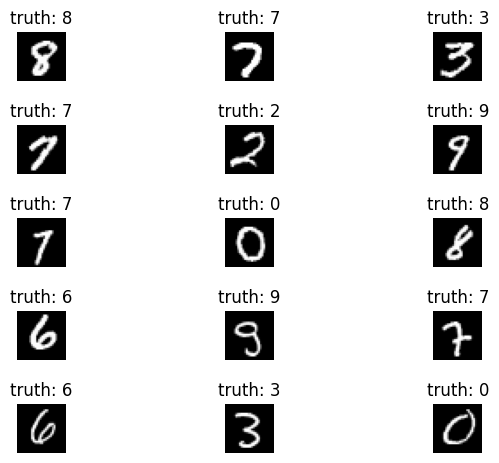

In [4]:
show_random_images(x, y)

In [5]:
# create validation set with 10,000 images and training set with 50,000 images
indexes = numpy.arange(y.shape[0])
rng = numpy.random.default_rng(34)
rng.shuffle(indexes)

K = 10000

val_indexes = indexes[:K]
train_indexes = indexes[K:]
del(indexes)

print(val_indexes.shape, train_indexes.shape)

(10000,) (50000,)


In [6]:
# Creates our MLP model class.
class Model:
    def __init__(self):
        self.layers = [engine.Linear(784, 100), engine.Activation(), engine.BatchNorm1d(100), 
                       engine.Linear(100, 100), engine.Activation(), engine.BatchNorm1d(100),
                       engine.Linear(100, 100), engine.Activation(), engine.BatchNorm1d(100),
                       engine.Linear(100, 10), engine.Activation(), engine.BatchNorm1d(10)]
        self.n_parameters = sum([layer.n_parameters for layer in self.layers])
    
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def update(self, learning_rate):
        for layer in self.layers:
            layer.update(learning_rate)
        
    def predict(self, x):
        for layer in self.layers:
            x = layer.predict(x)
        return x

In [7]:
# For logging accuracy estimates during training
def estimate_accuracy(sample_size=500):
    global rng, train_indexes, val_indexes, x, y, model
    train_correct = 0
    val_correct = 0
    for j, indexes_ in enumerate([train_indexes, val_indexes]):
        sample = rng.integers(indexes_.shape[0], size=sample_size)
        batch_indexes = indexes_[sample]
        x_batch = x[batch_indexes]
        y_batch = y[batch_indexes]
        logits = model.predict(x_batch)
        predictions = engine.predict_class(logits)
        correct = (predictions == y_batch.data).sum()
        if j == 0:
            train_correct += correct
        else:
            val_correct += correct
        
    return train_correct / sample_size, val_correct / sample_size

# Calculates accuracy over whole training/val/testing sets
def get_accuracy(x_, y_):
    global model
    logits = model.predict(x_)
    predictions = engine.predict_class(logits)
    return (predictions == y_.data).sum() / y_.shape[0]

In [8]:
# Initialize our model
model = Model()
model.n_parameters

100330

In [10]:
n_epochs = 30
batch_size = 100
n_batches = train_indexes.shape[0] // batch_size
learning_rate = 1e-3

estimated_train_accuracy = [0.0] * n_epochs
estimated_val_accuracy = [0.0] * n_epochs

# Training our model
for i in range(n_epochs):
    for j in range(n_batches):
        
        # get batch
        batch_indexes = train_indexes[j * batch_size: (j + 1) * batch_size]
        x_batch = x[batch_indexes]
        y_batch = y[batch_indexes]
        
        # forward pass
        logits = model.forward(x_batch)
        loss = engine.classification_loss(logits, y_batch)
        
        # backward pass
        loss.backward()
        
        # update (gradients are automatically zero'd)
        model.update(learning_rate)
    
        print('\repoch:', i + 1, 'batch:', j + 1, end='')
    # log accuracy estimates
    estimated_train_accuracy[i], estimated_val_accuracy[i] = estimate_accuracy()

epoch: 30 batch: 500

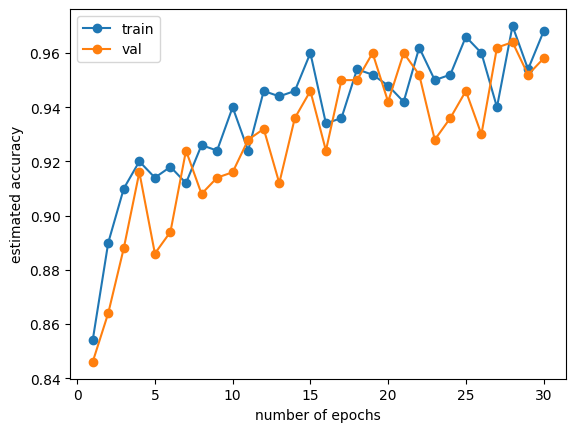

In [11]:
dummy = range(1, n_epochs + 1)
pyplot.plot(dummy, estimated_train_accuracy, 'o-')
pyplot.plot(dummy, estimated_val_accuracy, 'o-')
pyplot.xlabel('number of epochs')
pyplot.ylabel('estimated accuracy')
pyplot.legend(['train', 'val']);

In [12]:
# validation accuracy of about 95.2%
get_accuracy(x[val_indexes], y[val_indexes])

0.9524

In [13]:
del(x, y)
# get our test set
testing_images_path = "data/t10k-images.idx3-ubyte"
testing_labels_path = "data/t10k-labels.idx1-ubyte"

x_test, y_test = load_mnist_data(testing_images_path, testing_labels_path)
x_test.shape, y_test.shape

((10000, 784), (10000,))

In [14]:
# test accuracy of about 95.5%
get_accuracy(x_test, y_test)

0.955

In [15]:
def show_random_predictions(images, labels, rows=5, cols=3):
    indexes = numpy.random.randint(labels.shape[0], size=rows * cols)
    figure, axes = pyplot.subplots(rows, cols)
    figure.tight_layout()
    count = 0
    for i in range(rows):
        for j in range(cols):
            k = indexes[count]
            
            x = images[k]
            logits = model.predict(x)
            prediction = engine.predict_class(logits)
            title = f'predicted: {prediction}, truth:' + str(labels[k].data.item())

            x = x.data.reshape((28, 28))
            axes[i][j].imshow(x, cmap=pyplot.cm.gray)
            axes[i][j].set_title(title)
            axes[i][j].set_axis_off()
            count += 1

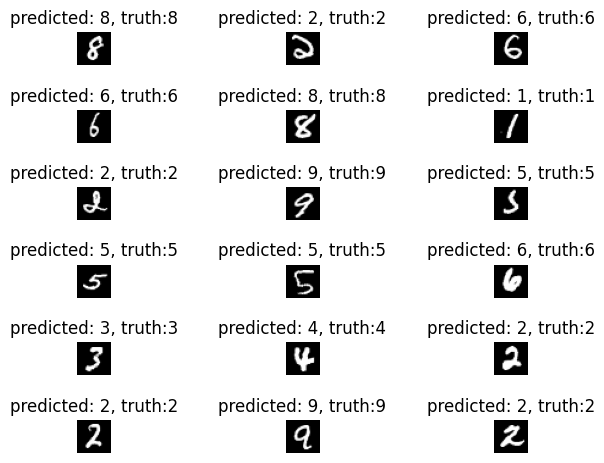

In [16]:
# display some random predictions our model makes
show_random_predictions(x_test, y_test, 6, 3)